# Chicken-heart trajectories and interactions

This notebook calculates the cell-type transitions, velocity components, and
interaction networks used in the chicken-heart analysis. It continues from the
daily populations generated in the [chicken-heart notebook](../dataset_workflows/chicken_heart.ipynb).
Run that notebook first, including its final cell that saves the populations.

The input is its `manifest.json`, together with the daily H5AD files, aligned
observations, and trained model. There is no additional training here. The
growth calculations and plots are in the preceding notebook. S7–S8 are covered
by the separate [alignment analysis](chicken_heart_alignment.md).

## Read the daily populations

Open this notebook in JupyterLab after following the
[installation instructions](../../installation.md). Use the same data directory
as in the preceding notebook. If you changed `CYTOBRIDGE_HEART_OUTPUT_DIR`, keep
that setting here so that `population_dir` points to the populations you saved.

In [1]:
from pathlib import Path
import json
import os

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import CytoBridge as cb

from reproduction.chicken_heart.downstream_helpers.heart import (
    HEART_LABEL_TO_COLOR, prepare_data_for_side_by_side_2d,
    plot_side_by_side_spatial_with_custom_colors, plot_celltype_stackbar,
    plot_segment_network_evolution,
)
from reproduction.chicken_heart.downstream_helpers.heart_lineage_functions import (
    prepare_multi_timepoint_adata, plot_lineage_transition,
)
from reproduction.chicken_heart.velocity import plot_daily_velocity_stream_grid

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
data = project / "data/chicken_heart"
heart_output = Path(os.environ.get("CYTOBRIDGE_HEART_OUTPUT_DIR",
                                  project / "outputs/chicken_heart_paper"))
population_dir = heart_output / "new_runs_formal_trained/formal_daily_piecewise_interpolation_celltypecorrected"
output = project / "outputs/chicken_heart_analysis"
output.mkdir(parents=True, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"font.family": "Arial", "pdf.fonttype": 42,
                     "svg.fonttype": "none", "text.color": "black"})

manifest = json.loads((population_dir / "manifest.json").read_text())
records = sorted(manifest["slices"], key=lambda item: item["time_float"])
pd.DataFrame(records)[["time_label", "time_float", "is_observed", "n_cells"]]

,time_label,time_float,is_observed,n_cells
0,D4,0.000000,True,147
1,D5,0.333333,False,248
2,D6,0.666667,False,368
3,D7,1.000000,True,528
4,D8,1.333333,False,676
5,D9,1.666667,False,865
6,D10,2.000000,True,908
7,D11,2.250000,False,1089
8,D12,2.500000,False,1366
9,D13,2.750000,False,1824


In [2]:
populations, communication_populations, times = {}, {}, {}
for record in records:
    label = record["time_label"]
    times[label] = float(record["time_float"])
    for field, folder, destination in (
        ("slice_h5ad", "slice_data", populations),
        ("communication_h5ad", "communication_slice_data", communication_populations),
    ):
        # Resolve relative to this run so the project can be moved to another computer.
        path = population_dir / folder / Path(record[field]).name
        cells = ad.read_h5ad(path)
        cells.obs["celltype_prediction"] = cells.obs["celltype_prediction"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        cells.obsm["spatial"] = np.asarray(cells.X[:, :2], dtype=np.float32)
        cells.uns["is_observed"] = bool(record["is_observed"])
        destination[label] = cells

days = list(populations)
observed_days = [r["time_label"] for r in records if r["is_observed"]]
palette = {label: HEART_LABEL_TO_COLOR[label]
           for label in sorted({str(x) for cells in populations.values()
                                for x in cells.obs["celltype_prediction"]})}
counts = pd.DataFrame({day: cells.obs["celltype_prediction"].value_counts()
                       for day, cells in populations.items()}).fillna(0).astype(int)
fractions = counts.div(counts.sum(axis=0), axis=1)
counts.to_csv(output / "celltype_counts.csv")
fractions.to_csv(output / "celltype_fractions.csv")
fractions

,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14
celltype_prediction,,,,,,,,,,,
Cardiomyocytes-1,0.006803,0.032258,0.086957,0.149621,0.195266,0.223121,0.247797,0.276400,0.311859,0.360197,0.496695
Cardiomyocytes-2,0.000000,0.008065,0.013587,0.018939,0.005917,0.001156,0.000000,0.000000,0.000000,0.000000,0.000508
Endocardial cells,0.217687,0.213710,0.163043,0.168561,0.167160,0.150289,0.071586,0.066116,0.054905,0.042215,0.014235
Epi-epithelial cells,0.013605,0.020161,0.035326,0.068182,0.084320,0.092486,0.092511,0.095500,0.063690,0.031798,0.003050
Erythrocytes,0.000000,0.004032,0.008152,0.064394,0.075444,0.120231,0.146476,0.156107,0.152269,0.154605,0.122522
Fibroblast cells,0.000000,0.000000,0.000000,0.001894,0.005917,0.017341,0.013216,0.022957,0.059297,0.133224,0.134215
Immature myocardial cells,0.414966,0.483871,0.502717,0.382576,0.356509,0.313295,0.289648,0.252525,0.199122,0.136513,0.103203
MT-enriched cardiomyocytes,0.000000,0.000000,0.000000,0.034091,0.026627,0.003468,0.012115,0.005510,0.002196,0.001096,0.000000
Macrophages,0.000000,0.000000,0.000000,0.005682,0.004438,0.005780,0.003304,0.005510,0.007321,0.002741,0.001525


## Plot the daily populations

The spatial panels use the coordinates and predicted cell types in each H5AD
file. The stacked bars show the cell-type fractions calculated above.

全局最大跨度: 2.60, 统一缩放因子: 384.0172


图像已保存到: outputs/chicken_heart_analysis/daily_populations.pdf


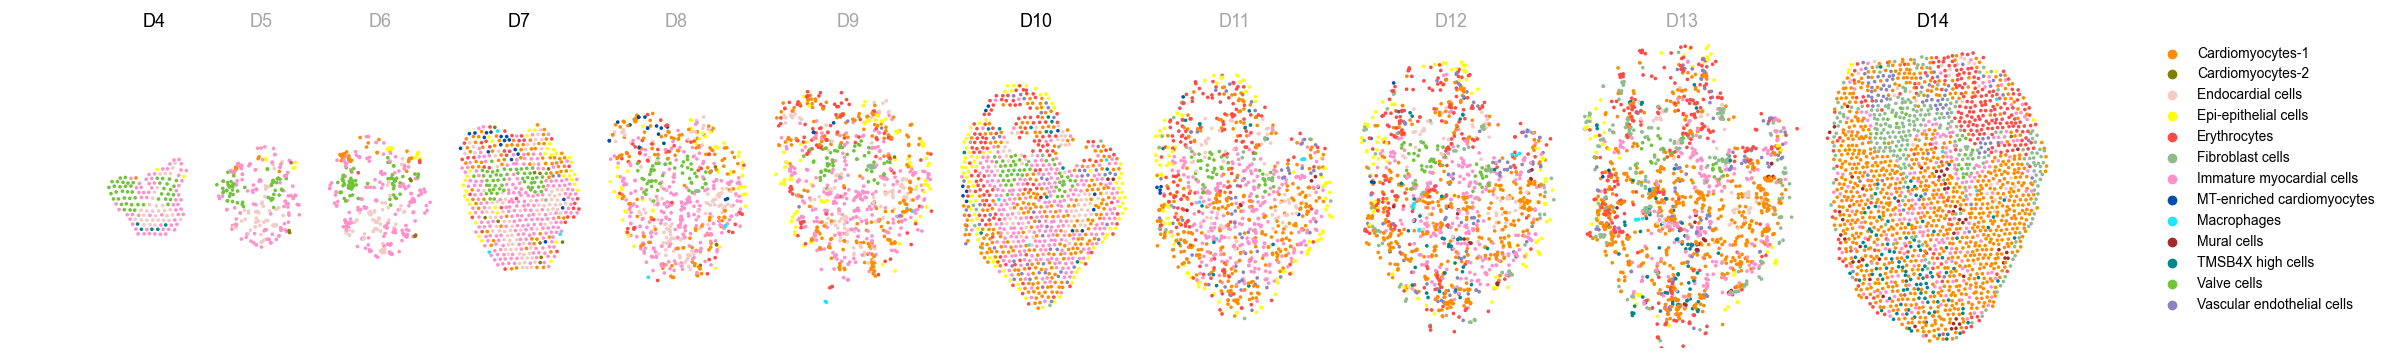

Stackbar plot saved to outputs/chicken_heart_analysis/celltype_fractions.pdf


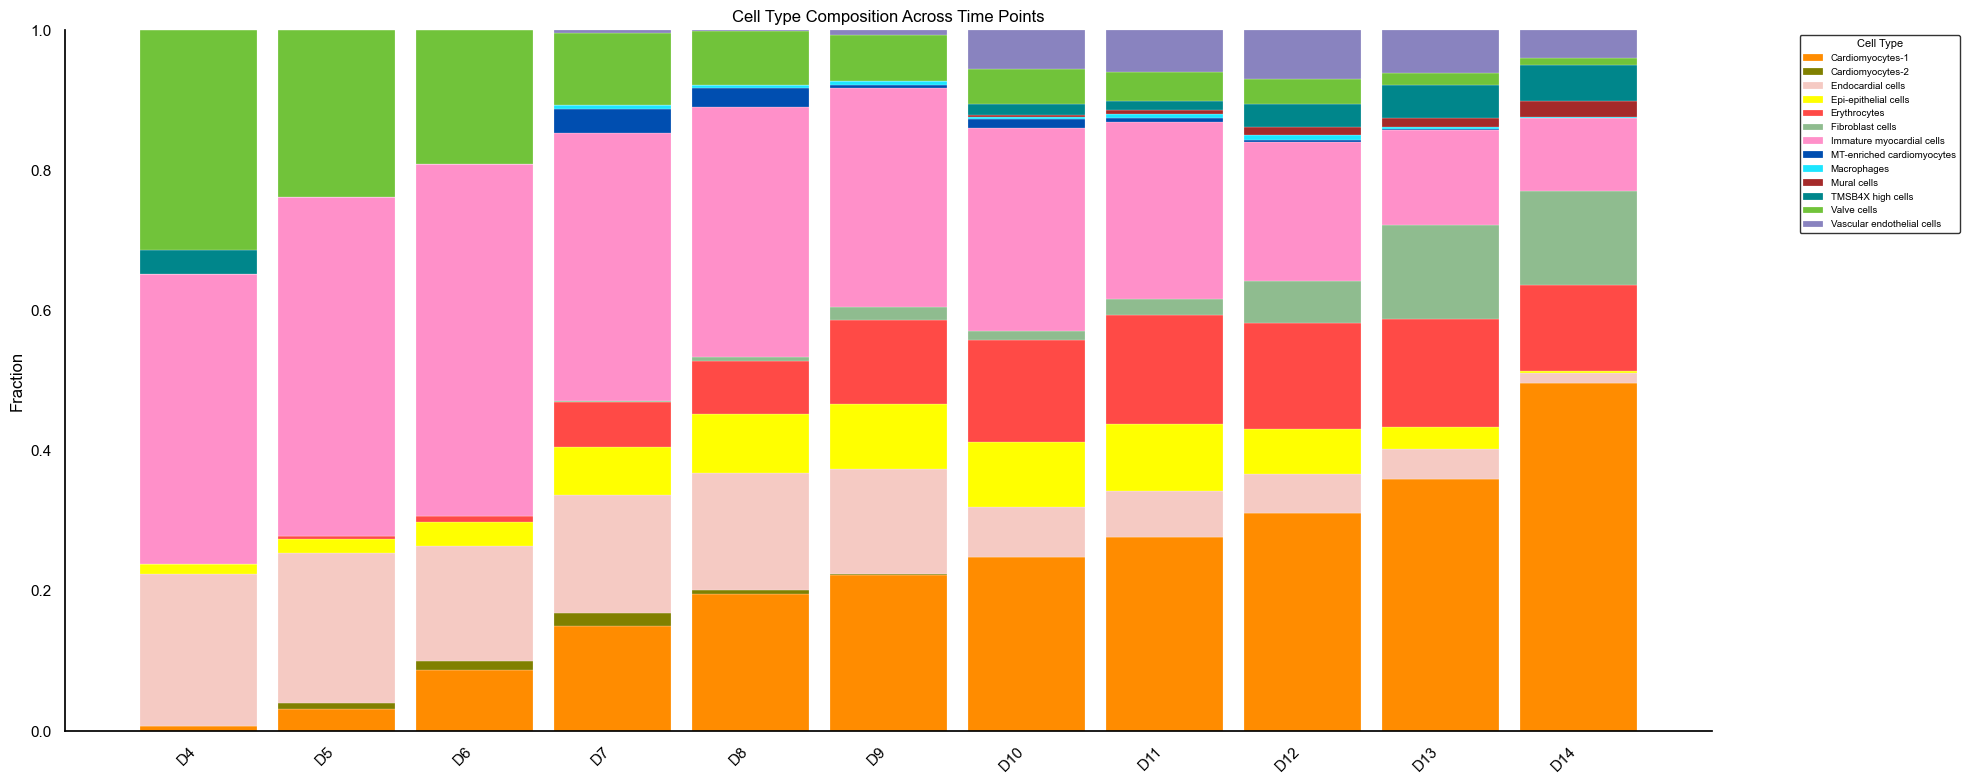

In [3]:
spatial = prepare_data_for_side_by_side_2d(
    adata_dict=populations, time_keys=days, spatial_key="spatial",
    spacing=100, target_size=1000, label_to_color=palette,
)
plot_side_by_side_spatial_with_custom_colors(
    spatial, color_by="celltype_prediction", time_key="original_timepoint",
    spot_size=12, figsize=(24, 9), save_path=output / "daily_populations.pdf",
)
plot_celltype_stackbar(
    adata_dict=populations, time_keys=days, label_to_color=palette,
    annotation_key="celltype_prediction", save_path=output / "celltype_fractions.pdf",
)

## Calculate velocity components

`compute_velocity_components` evaluates total, intrinsic-context, and interaction
velocity at each cell state. `full` includes intrinsic drift, interaction, and
the score correction. Each returned array has two spatial columns followed
by 50 expression-PC columns. The next cell saves these arrays before plotting.

In [4]:
loaded = cb.tl.load_dynamical_model_from_dir(
    data / "model", dim=52, device=device,
    edge_predictor_path=data / "edge_classifier/chicken_heart_edge_model.pt",
)
runtime = cb.tl.build_dynamical_runtime(loaded)
model = loaded.model
cutoff = float(model.interaction_net.cutoff)
cb.tl.set_global_random_seed(42)
velocity = {}
for day in days:
    velocity[day] = cb.tl.compute_velocity_components(
        data=np.asarray(populations[day].X, dtype=np.float32),
        time_value=times[day], model=model, interaction_m=1024,
        interaction_threshold=cutoff, device=device, spatial_dim=2,
    )
    np.savez_compressed(output / f"velocity_{day}.npz", **velocity[day])
pd.DataFrame({day: {component: values.shape for component, values in fields.items()}
              for day, fields in velocity.items()})

,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14
drift,"(147, 52)","(248, 52)","(368, 52)","(528, 52)","(676, 52)","(865, 52)","(908, 52)","(1089, 52)","(1366, 52)","(1824, 52)","(1967, 52)"
interaction,"(147, 52)","(248, 52)","(368, 52)","(528, 52)","(676, 52)","(865, 52)","(908, 52)","(1089, 52)","(1366, 52)","(1824, 52)","(1967, 52)"
score,"(147, 52)","(248, 52)","(368, 52)","(528, 52)","(676, 52)","(865, 52)","(908, 52)","(1089, 52)","(1366, 52)","(1824, 52)","(1967, 52)"
full,"(147, 52)","(248, 52)","(368, 52)","(528, 52)","(676, 52)","(865, 52)","(908, 52)","(1089, 52)","(1366, 52)","(1824, 52)","(1967, 52)"


### Project expression velocity onto the tissue

For the observed stages, the plotting function builds a 30-neighbor graph in
expression-PC space. It uses scVelo to project the PC velocity onto the spatial
coordinates and draw streamlines. Colors mark the anatomical regions stored in
the aligned observations. This projection uses the expression columns of the
velocity arrays, rather than the two spatial-velocity columns.

computing velocity graph (using 1/160 cores)


  0%|          | 0/147 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


  0%|          | 0/528 [00:00<?, ?cells/s]

...

  0%|          | 0/908 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


  0%|          | 0/1967 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


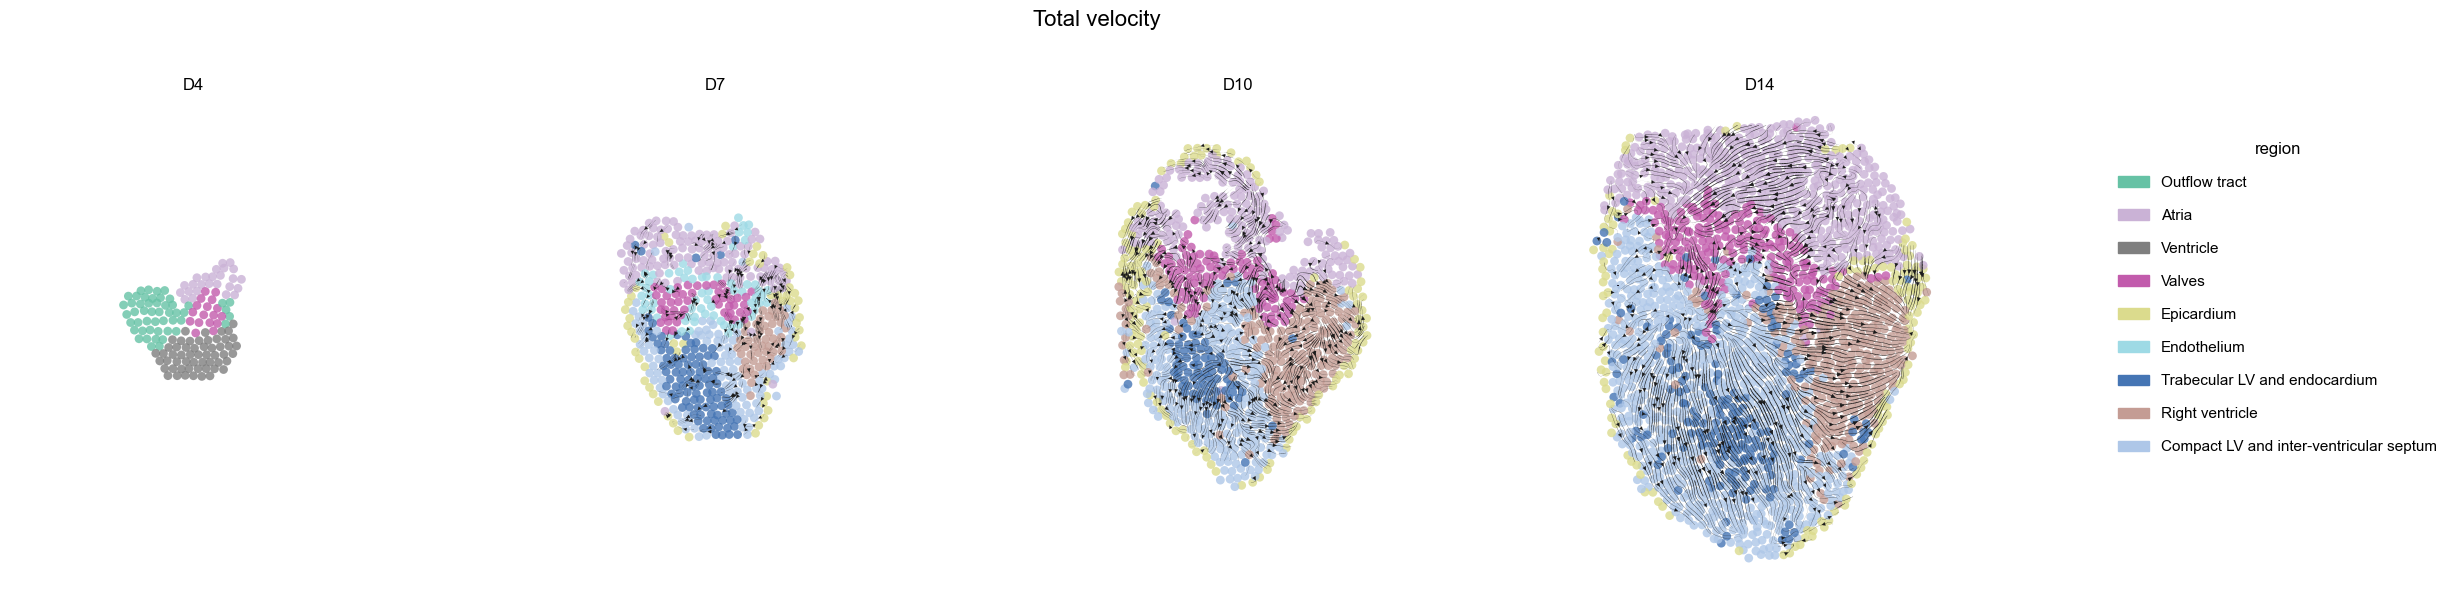

computing velocity graph (using 1/160 cores)


  0%|          | 0/147 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


  0%|          | 0/528 [00:00<?, ?cells/s]

...

  0%|          | 0/908 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


  0%|          | 0/1967 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


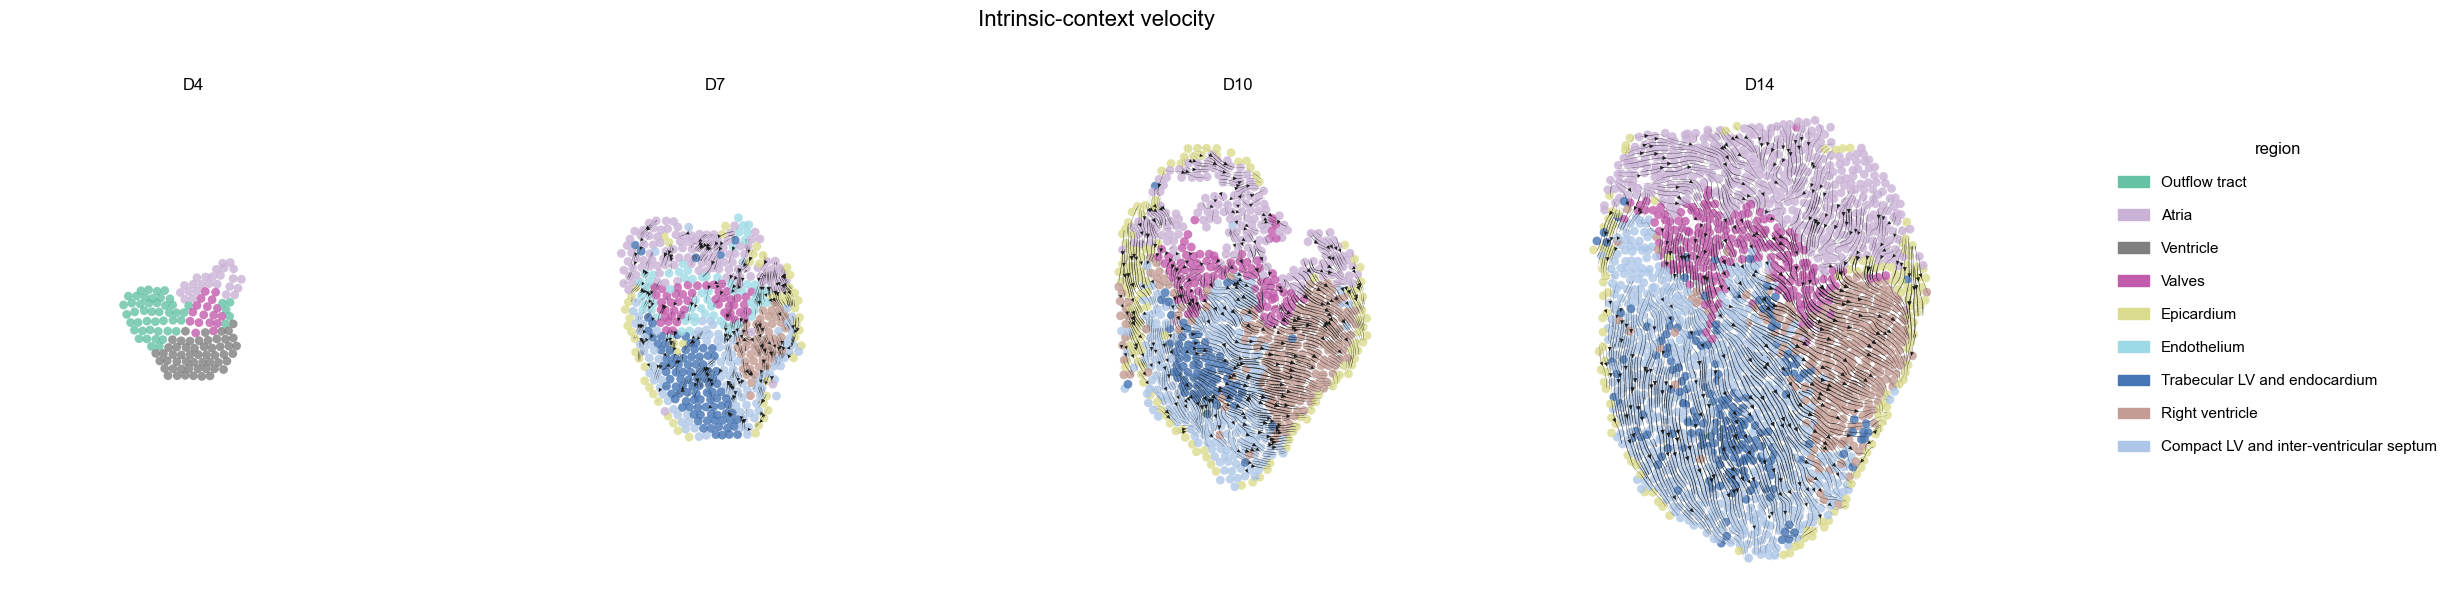

computing velocity graph (using 1/160 cores)


  0%|          | 0/147 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


  0%|          | 0/528 [00:00<?, ?cells/s]

...

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


  0%|          | 0/1967 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


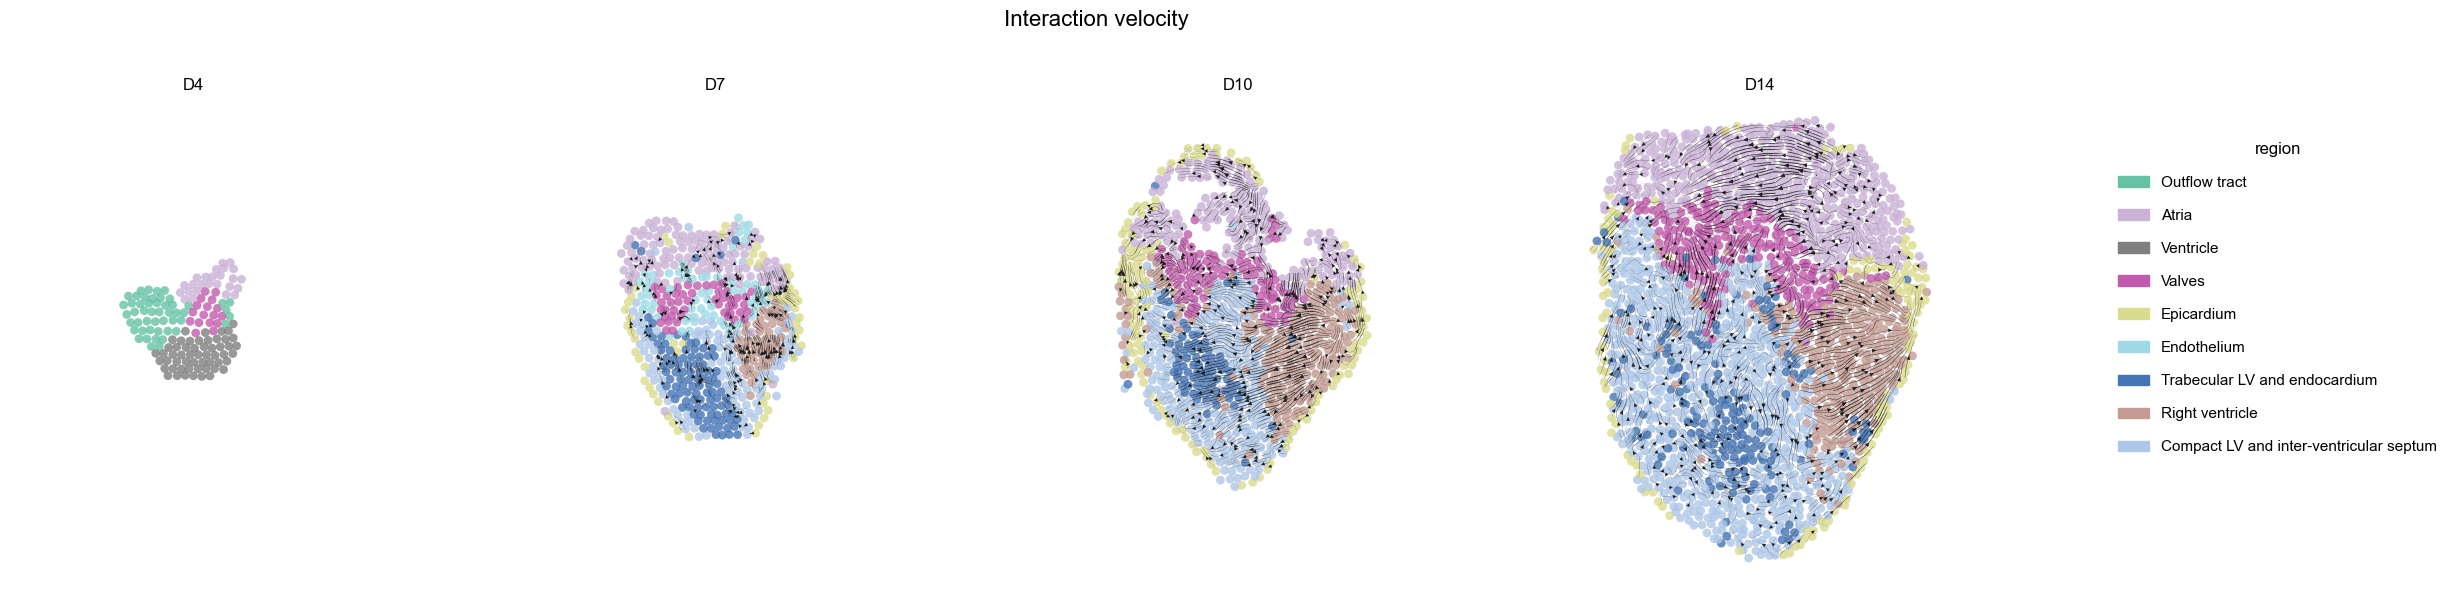

In [5]:
reference = ad.read_h5ad(data / "aligned.h5ad", backed="r")
regions = reference.obs["region"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
observed = {day: populations[day] for day in observed_days}
for cells in observed.values():
    cells.obs["region"] = regions.loc[cells.obs_names].values
reference.file.close()

region_colors = {
    "Ventricle": "#7f7f7f", "Outflow tract": "#66c2a5",
    "Endothelium": "#9edae5", "Valves": "#c25bac", "Atria": "#cab2d6",
    "Epicardium": "#dbdb8d", "Trabecular LV and endocardium": "#4575b4",
    "Compact LV and inter-ventricular septum": "#aec7e8", "Right ventricle": "#c49c94",
}
for component in ("full", "drift", "interaction"):
    plot_daily_velocity_stream_grid(
        adata_dict=observed, velocity_by_time=velocity, palette=region_colors,
        color_key="region", component_key=component,
        save_path=output / f"velocity_{component}.svg",
    )

## Calculate cell-type transitions

Starting from each source population, we integrate the total velocity to the next
selected day using Euler steps of at most 0.05 model-time units. We then classify
the resulting states with the same cell-type classifier used for the daily
populations. Counting source and destination labels gives a transition matrix.
Each row is divided by its source-cell count to give transition fractions.

In [6]:
classifier = cb.tl.load_cached_mlp_classifier(
    str(data / "classifier_cache/classifier_resmlp_432f09f20ff65c0d.pt"), device=device,
)

def calculate_transition(source_day, target_day):
    source = populations[source_day]
    points = np.asarray(source.X, dtype=np.float32).copy()
    start, end = times[source_day], times[target_day]
    steps = max(1, int(np.ceil((end - start) / 0.05)))
    dt = (end - start) / steps
    time = start
    for _ in range(steps):
        field = cb.tl.compute_velocity_components(
            data=points, time_value=time, model=model, interaction_m=1024,
            interaction_threshold=cutoff, device=device, spatial_dim=2,
        )["full"]
        points += np.asarray(field, dtype=np.float32) * np.float32(dt)
        time += dt
    labels = cb.tl.predict_labels_for_points(
        points=points, time_value=end, model=classifier.model,
        label_encoder=classifier.label_encoder, feature_dim=classifier.feature_dim,
        device=device, knn_neighbors=1,
        include_time_feature=classifier.include_time_feature, spatial_coords=points[:, :2],
    )
    source_labels = source.obs["celltype_prediction"].astype(str).to_numpy()
    types = sorted(set(source_labels) | set(labels))
    counts = pd.crosstab(source_labels, np.asarray(labels)).reindex(index=types, columns=types, fill_value=0)
    fractions = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    counts.to_csv(output / f"transition_counts_{source_day}_{target_day}.csv")
    fractions.to_csv(output / f"transition_fractions_{source_day}_{target_day}.csv")
    return fractions

sequences = {"cardiomyocytes": ["D4", "D7", "D10", "D14"],
             "epicardial_fibroblast": ["D10", "D12", "D14"]}
pairs = list(dict.fromkeys(pair for sequence in sequences.values()
                          for pair in zip(sequence[:-1], sequence[1:])))
cb.tl.set_global_random_seed(42)
transitions = {pair: calculate_transition(*pair) for pair in pairs}
transitions[("D4", "D7")]

col_0,Cardiomyocytes-1,Endocardial cells,Epi-epithelial cells,Erythrocytes,Immature myocardial cells,TMSB4X high cells,Valve cells
row_0,,,,,,,
Cardiomyocytes-1,1.000000,0.0000,0.0,0.000000,0.000000,0.0,0.000000
Endocardial cells,0.062500,0.5625,0.0,0.093750,0.250000,0.0,0.031250
Epi-epithelial cells,0.000000,0.0000,0.5,0.000000,0.500000,0.0,0.000000
Erythrocytes,0.000000,0.0000,0.0,0.000000,0.000000,0.0,0.000000
Immature myocardial cells,0.213115,0.0000,0.0,0.065574,0.721311,0.0,0.000000
TMSB4X high cells,0.000000,0.0000,0.0,0.000000,1.000000,0.0,0.000000
Valve cells,0.000000,0.0000,0.0,0.021739,0.260870,0.0,0.717391


### Plot the transitions

The following panels draw the transition fractions on the spatial populations.
The display settings select the cell types shown in each panel. The CSV files
above retain the complete matrices, before selecting cell types for display.
On each connection, the percentage near the source is the fraction that reaches
the destination cell type. The percentage near the destination is that source
type's share of all predicted arrivals into the destination.

In [7]:
def plot_transitions(sequence, name, settings, figsize, order=None):
    spatial = prepare_multi_timepoint_adata(
        data_list=[np.asarray(populations[day].X, dtype=np.float32) for day in sequence],
        labels_list=[populations[day].obs["celltype_prediction"].astype(str).to_numpy() for day in sequence],
        timepoint_labels=sequence, gap_scale=0.2, space=0.2, align_bottom=True,
    )
    plot_lineage_transition(
        adata_combined=spatial,
        transition_matrices={pair: transitions[pair] for pair in zip(sequence[:-1], sequence[1:])},
        time_keys=sequence,
        label_to_color=palette, step_configs=settings, figsize=figsize,
        fixed_ct_order=order, save_path=str(output / f"{name}.pdf"),
    )
    plt.show()

X range: 0.0 to 5.541991233825684
DEBUG: time_keys received = ['D4', 'D7', 'D10', 'D14']
DEBUG: adata timepoints = ['D4', 'D7', 'D10', 'D14']
Categories (4, object): ['D4' < 'D7' < 'D10' < 'D14']


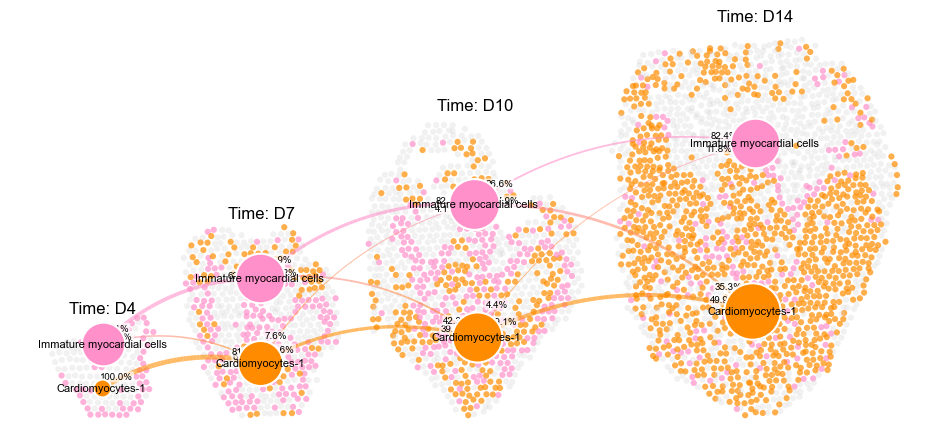

In [8]:
cardiomyocyte_step_configs = {
    ("D4", "D7"): {
        "exclude": sorted(
            set(palette)
            - {"Cardiomyocytes-1", "Immature myocardial cells"}
        ),
        "focus_source": ["Immature myocardial cells"],
        "focus_target": ["Cardiomyocytes-1", "Immature myocardial cells"],
    },
    ("D7", "D10"): {
        "exclude": sorted(
            set(palette)
            - {"Cardiomyocytes-1", "Immature myocardial cells"}
        ),
        "focus_source": ["Cardiomyocytes-1", "Immature myocardial cells"],
        "focus_target": ["Cardiomyocytes-1", "Immature myocardial cells"],
    },
    ("D10", "D14"): {
        "exclude": sorted(
            set(palette)
            - {"Cardiomyocytes-1", "Immature myocardial cells"}
        ),
        "focus_source": ["Cardiomyocytes-1", "Immature myocardial cells"],
        "focus_target": ["Cardiomyocytes-1", "Immature myocardial cells"],
    },
}
cardiomyocyte_fixed_order = {
    "Immature myocardial cells": 0,
    "Cardiomyocytes-1": 1,
}

plot_transitions(sequences["cardiomyocytes"], "cardiomyocyte_transitions",
                 cardiomyocyte_step_configs, (12, 6), cardiomyocyte_fixed_order)

X range: 0.0 to 5.309869289398193
DEBUG: time_keys received = ['D10', 'D12', 'D14']
DEBUG: adata timepoints = ['D10', 'D12', 'D14']
Categories (3, object): ['D10' < 'D12' < 'D14']


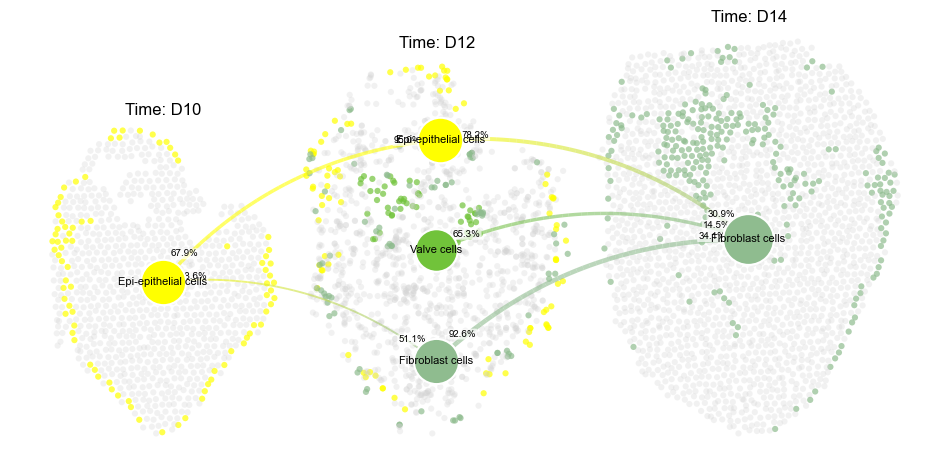

In [9]:
epi_to_fib_step_configs = {
    ("D10", "D12"): {
        "focus_source": ["Epi-epithelial cells"],
        "focus_target": [],
        "exclude": [
            "Erythrocytes", "Macrophages", "Endocardial cells", "Vascular endothelial cells",
            "TMSB4X high cells", "Cardiomyocytes-1", "Immature myocardial cells",
            "MT-enriched cardiomyocytes", "Cardiomyocytes-2", "Mural cells",
        ],
    },
    ("D12", "D14"): {
        "focus_source": [],
        "focus_target": ["Fibroblast cells"],
        "exclude": [
            "Erythrocytes", "Macrophages", "Endocardial cells", "Vascular endothelial cells",
            "TMSB4X high cells", "Mural cells", "Cardiomyocytes-1", "Immature myocardial cells",
            "MT-enriched cardiomyocytes", "Cardiomyocytes-2",
        ],
    },
}

plot_transitions(sequences["epicardial_fibroblast"], "epicardial_fibroblast_transitions",
                 epi_to_fib_step_configs, (12, 6))

## Calculate cell-type interactions

The preceding notebook saves a separate set of populations for interaction
analysis in `communication_slice_data`. Here, `compute_timepoint_communications`
evaluates the model's attention scores and aggregates them by sender and receiver
cell type. `M_per_source` divides the summed attention by the number of sender
cells. The next cell saves this matrix for each day. The network panel draws the
stronger entries from those newly calculated matrices, with node size based on
cell-type abundance.

In [10]:
cb.tl.set_global_random_seed(42)
communication = cb.tl.compute_timepoint_communications(
    adata_dict={str(times[day]): cells for day, cells in communication_populations.items()},
    time_points=[times[day] for day in days], annotation_key="celltype_prediction",
    f_net=runtime.f_net, device=device, out_dir=str(output / "attention"),
    remove_self_loop=False, winsor_quantile=0.995,
    save_pickle_path=str(output / "communication_by_day.pkl"),
)
communication = {day: communication[str(times[day])] for day in days}
for day, values in communication.items():
    table = pd.DataFrame(values["M_per_source"], index=values["types"], columns=values["types"])
    table.index.name = "sender"
    table.columns.name = "receiver"
    table.to_csv(output / f"interaction_per_sender_{day}.csv")
plt.close("all")
pd.read_csv(output / "interaction_per_sender_D4.csv", index_col=0)

Time 0.0 cells 147 of 147
Time 0.3333333333333333 cells 248 of 248
Time 0.6666666666666666 cells 368 of 368
Time 1.0 cells 528 of 528
Time 1.3333333333333333 cells 676 of 676
Time 1.6666666666666667 cells 865 of 865
Time 2.0 cells 908 of 908
Time 2.25 cells 1089 of 1089
Time 2.5 cells 1366 of 1366
Time 2.75 cells 1824 of 1824
Time 3.0 cells 1967 of 1967


Saved: outputs/chicken_heart_analysis/communication_by_day.pkl


,Cardiomyocytes-1,Endocardial cells,Epi-epithelial cells,Immature myocardial cells,TMSB4X high cells,Valve cells
sender,,,,,,
Cardiomyocytes-1,0.000000,15.953776,4.769215,92.559809,0.000000,120.633898
Endocardial cells,0.515232,93.634290,1.799207,96.081851,13.158306,51.884730
Epi-epithelial cells,2.741169,33.831200,0.000000,77.209694,0.000000,52.583390
Immature myocardial cells,1.711927,56.522158,2.494756,75.677624,6.978208,61.778464
TMSB4X high cells,0.000000,93.033589,0.000000,81.804929,17.100628,10.488636
Valve cells,2.880781,36.747212,1.968781,78.417023,1.106178,120.618045


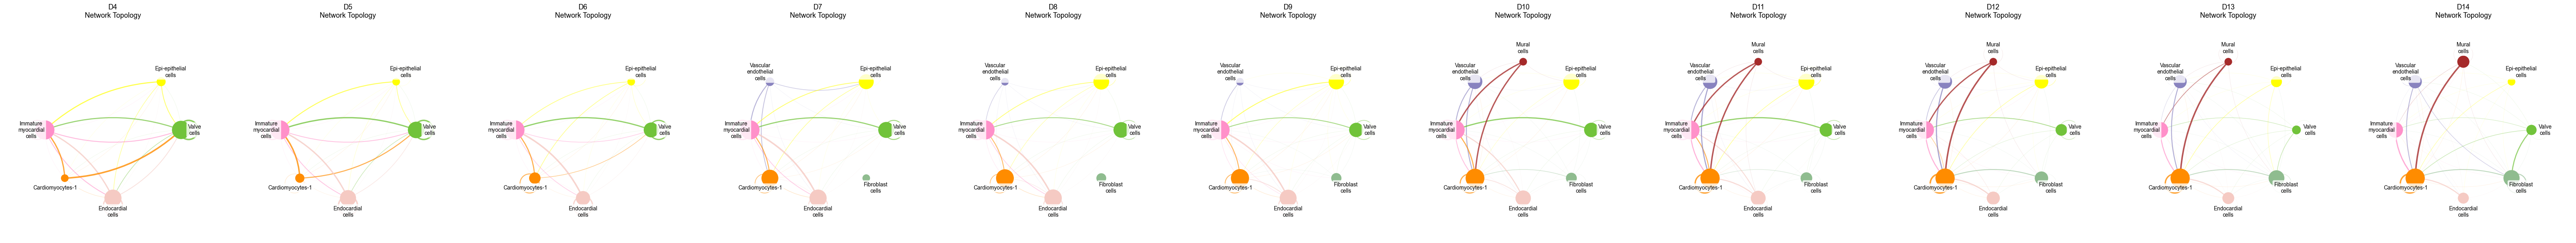

PosixPath('outputs/chicken_heart_analysis/D4_to_D14/network_evolution_global.svg')

In [11]:
plot_segment_network_evolution(
    segment_name="D4_to_D14", segment_labels=days, adata_dict=populations,
    all_time_communications=communication, label_to_color=palette,
    exclude_types=["Erythrocytes", "Macrophages", "Cardiomyocytes-2",
                   "MT-enriched cardiomyocytes", "TMSB4X high cells"],
    output_dir=output,
)

The tables, velocity arrays, and plots are saved in
`outputs/chicken_heart_analysis/` under your data project. To use another fitted
model on the same populations, change the model directory in the loading cell
and run the velocity, transition, and interaction sections again.